# Adaptive collocation sampling for PINN training

In this notebook, we investigate the impact of adaptive sampling strategies on training of PINNs. 
In particular, we consider:

- **Uniform** — $30$ collocation points drawn uniformly once on $[-1,1]\times[0,1]$ and held fixed.
- **RAR / RAR-G** — *Residual-based Adaptive Refinement, greedy*: every $T$ iterations, the **top-$k$ residual** points from a large uniform candidate pool are *added* to the collocation set. The set of collocation points grows over training.\n
- **RAD** — *Residual-based Adaptive Distribution* (importance sampling): every $T$ iterations the entire collocation set is *redrawn* from the density $p(x)\propto |r(x;\theta)|^k/\mathbb E[|r|^k]+c$, with $(k=1, c=1)$ as the Wu et al. default. The dataset size stays fixed, but the collocation points are moved.

**Test problem [Wu et al.'23, Section 3.2]:** 1D diffusion with manufactured source on $\Omega\times(0,T]=[-1,1]\times[0,1]$,
$$u_t = u_{xx} + e^{-t}\bigl(-\sin(\pi x) + \pi^2\sin(\pi x)\bigr), \quad u(x,0) = \sin(\pi x), \quad u(\pm 1, t) = 0.$$
Exact solution: $u_\star(x,t) = \sin(\pi x)\, e^{-t}$. The combined IC + BC + PDE specifies a unique solution; we evaluate $L^2$ accuracy against $u_\star$ on a $101\times 101$ test grid.

**Setup:**  4-hidden-layer $\times$ 32-neuron tanh PINN, soft IC + BC enforcement, full-batch Adam at $\eta=10^{-3}$ for $K=15{,}000$ iterations, $30$ initial residual points. The two runs use the *same* network initialisation and the *same* initial collocation set; the only difference is the sampling strategy.

In [18]:
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float64)

PI = math.pi

## 1. Problem setup

Manufactured solution and source are given in closed form; the test grid is $101\times 101$ on $[-1,1]\times[0,1]$.

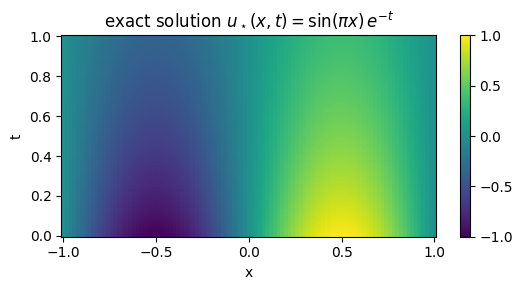

In [19]:
def u_exact(xt):
    """Manufactured exact solution u_*(x, t) = sin(pi x) exp(-t)."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.sin(PI * x) * torch.exp(-t)

def src(xt):
    """Source term so that u_* satisfies u_t = u_xx + src."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.exp(-t) * (-torch.sin(PI * x) + (PI ** 2) * torch.sin(PI * x))

def sample_uniform(N):
    """N uniform points on [-1,1] x [0,1]."""
    pts = torch.rand(N, 2)
    pts[:, 0] = pts[:, 0] * 2.0 - 1.0
    return pts

def make_ic_bc(n_ic=80, n_bc=80):
    """Equispaced IC and BC sample points (fixed across the run)."""
    xt_ic = torch.zeros(n_ic, 2)
    xt_ic[:, 0] = torch.linspace(-1, 1, n_ic)
    half = n_bc // 2
    xt_bc = torch.zeros(n_bc, 2)
    xt_bc[:half, 0] = -1.0; xt_bc[:half, 1] = torch.linspace(0, 1, half)
    xt_bc[half:, 0] =  1.0; xt_bc[half:, 1] = torch.linspace(0, 1, n_bc - half)
    return xt_ic, xt_bc

# Test grid for L2 error.
nx, nt = 101, 101
xx = torch.linspace(-1, 1, nx); tt = torch.linspace(0, 1, nt)
X_TEST, T_TEST = torch.meshgrid(xx, tt, indexing='xy')
TEST_XT = torch.stack([X_TEST.reshape(-1), T_TEST.reshape(-1)], dim=1)
TEST_U  = u_exact(TEST_XT)

# Visualise the exact solution.
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.0))
im = ax.pcolormesh(X_TEST.numpy(), T_TEST.numpy(),
                   TEST_U.reshape(nt, nx).numpy(), shading='auto', cmap='viridis')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title(r'exact solution $u_\star(x,t) = \sin(\pi x)\,e^{-t}$')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 2. PINN model and loss

We use a tanh-MLP with 4 hidden layers of width 32. 
The boundary and initial conditions are enforced via soft penalty terms, i.e., the loss is
$$\mathcal{L}(\theta) = \frac{1}{m_\Omega}\sum_j r(x_j, t_j; \theta)^2 \;+\; \frac{1}{m_{\mathrm{IC}}}\sum_j \bigl(u_\theta(x_j, 0) - \sin(\pi x_j)\bigr)^2 \;+\; \frac{1}{m_{\mathrm{BC}}}\sum_j u_\theta(\pm 1, t_j)^2,$$
where $r(x,t;\theta) = \partial_t u_\theta - \partial_{xx} u_\theta - s(x,t)$ is the PDE residual. The IC and BC sample sets are fixed equispaced grids of size $80$ each; only the *interior* PDE collocation set is subject to the sampling strategy.

In [20]:
class PINN(nn.Module):
    """Standard tanh-MLP PINN with no hard BC encoding (BCs/ICs enter as soft losses)."""
    def __init__(self, depth=4, width=32):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        return self.net(xt)

def residual(model, xt):
    """PDE residual r(x,t;theta) = u_t - u_xx - s(x,t)."""
    g = xt.clone().detach().requires_grad_(True)
    u = model(g)
    grads = torch.autograd.grad(u, g, torch.ones_like(u), create_graph=True)[0]
    ux, ut = grads[..., 0:1], grads[..., 1:2]
    uxx = torch.autograd.grad(ux, g, torch.ones_like(ux), create_graph=True)[0][..., 0:1]
    return ut - uxx - src(g)

def loss_fn(model, xt_pde, xt_ic, xt_bc):
    L_pde = (residual(model, xt_pde) ** 2).mean()
    u_ic_pred = model(xt_ic).squeeze()
    u_ic_true = torch.sin(PI * xt_ic[:, 0])
    L_ic = ((u_ic_pred - u_ic_true) ** 2).mean()
    L_bc = (model(xt_bc) ** 2).mean()
    return L_pde + L_ic + L_bc

def l2_rel(model):
    """Relative L2 error of u_theta against the manufactured u_* on the test grid."""
    with torch.no_grad():
        u_pred = model(TEST_XT)
    return float(torch.sqrt(((u_pred - TEST_U) ** 2).sum() / (TEST_U ** 2).sum()))

## 3. RAR-G and RAD adaptive sampling

Two residual-based recipes from Wu et al. (2022 §2.3) are compared against the uniform baseline.

**RAR-G (greedy top-$k$):**

1. Train the PINN for some number of iterations on the current collocation set.
2. Sample a large uniform pool of candidates $\{\tilde x_\ell, \tilde t_\ell\}$ on $\Omega\times[0,T]$.
3. Evaluate $|r(\tilde x_\ell, \tilde t_\ell; \theta)|$.
4. *Append* the top-$k$ candidates with the largest $|r|$ to the collocation set.
5. Continue training. Repeat until total iterations exhausted.

Here, we consider $k=1$ points added every $1{,}000$ iterations starting from $30$ initial random points.

**RAD (residual-based adaptive distribution / importance sampling):**

RAD instead *resamples* the entire collocation set every $T$ iterations from a residual-based density,
$$
p_\theta(x) \;\propto\; \frac{|r(x;\theta)|^k}{\mathbb E\big[|r|^k\big]} \;+\; c,
\qquad k\!\ge\!1, \; c\!\ge\!0,
$$
which is equivalent to importance sampling for the PDE residual loss. The hyperparameters trade off concentration ($k$) and exploration ($c$): $c=0$ gives pure proportional-to-$|r|$ sampling, $c\to\infty$ recovers uniform sampling, and Wu et al. recommend $(k=1, c=1)$ as a robust default.

In contrast to RAR-G, the collocation budget for RAD stays fixed throughout training; the points just *move*. We use the same final budget as RAR-G for a fair comparison.


In [21]:
def rar_g_select(model, k, pool=10000):
    """Greedy top-k residual selector. Returns the k pool points with the
    largest |r(x;theta)|."""
    pool_xt = sample_uniform(pool)
    r = residual(model, pool_xt).detach().abs().squeeze()
    _, idx = torch.topk(r, k)
    return pool_xt[idx].detach()


def rad_select(model, m, pool=10000, k_exp=1.0, c=1.0):
    """Residual-based adaptive distribution (importance sampling) selector.

    Returns m points drawn without replacement from the candidate pool with
    probability proportional to |r|^k_exp / mean(|r|^k_exp) + c, matching
    Wu et al. 2022 (k=1, c=1 by default).
    """
    pool_xt = sample_uniform(pool)
    r = residual(model, pool_xt).detach().abs().squeeze()
    rk = r.pow(k_exp)
    p = rk / (rk.mean() + 1e-30) + c
    p = p / p.sum()
    idx = torch.multinomial(p, m, replacement=False)
    return pool_xt[idx].detach()


## 4. Training loop

Both runs use full-batch Adam at the same learning rate from the same initial parameters and the same initial $30$-point random sample. We log $L^2$ relative error every $500$ iterations.

In [22]:
ITERS          = 15000
LR             = 1e-3
N0             = 30        # initial residual collocation budget (paper: 30)
RESAMPLE_EVERY = 1000      # cadence of refinement / resampling
LOG_EVERY      = 500
N_RAD          = 44        # fixed budget for RAD (matches RAR-G's final size)
RAD_K          = 1.0       # RAD exponent k
RAD_C          = 1.0       # RAD additive constant c

def train(model, xt_pde, xt_ic, xt_bc, strategy='uniform',
          iters=ITERS, lr=LR, resample_every=RESAMPLE_EVERY, log_every=LOG_EVERY,
          n_add=1, n_rad=N_RAD, rad_k=RAD_K, rad_c=RAD_C):
    """Train PINN with full-batch Adam under one of three sampling strategies.

    strategy = 'uniform' | 'rar' | 'rad'
        - 'uniform' : the initial xt_pde set is held fixed for all iters.
        - 'rar'     : every resample_every iters, the top-`n_add` residual
                      points from a fresh uniform pool are *appended* (RAR-G).
        - 'rad'     : every resample_every iters, the entire collocation set
                      is *replaced* by `n_rad` points drawn from
                      p(x) ∝ |r|^rad_k / E[|r|^rad_k] + rad_c (importance
                      sampling, Wu et al. 2022 RAD).
    """
    xt = xt_pde.clone().detach()
    opt = optim.Adam(model.parameters(), lr=lr)

    history = {'iter': [], 'l2': [], 'n_pts': []}
    snapshots = [{'iter': 0, 'pts': xt.detach().cpu().numpy().copy()}]

    for k in range(iters):
        opt.zero_grad()
        L = loss_fn(model, xt, xt_ic, xt_bc)
        L.backward()
        opt.step()

        if (k + 1) % log_every == 0:
            history['iter'].append(k + 1)
            history['l2'].append(l2_rel(model))
            history['n_pts'].append(len(xt))

        if (k + 1) % resample_every == 0:
            if strategy == 'rar':
                xt_new = rar_g_select(model, n_add)
                xt = torch.cat([xt, xt_new], 0).detach()
                snapshots.append({'iter': k + 1,
                                  'pts': xt.detach().cpu().numpy().copy()})
            elif strategy == 'rad':
                xt = rad_select(model, n_rad,
                                k_exp=rad_k, c=rad_c).detach()
                snapshots.append({'iter': k + 1,
                                  'pts': xt.detach().cpu().numpy().copy()})

    history = {kk: np.array(vv) for kk, vv in history.items()}
    return {'history': history, 'snapshots': snapshots,
            'final_xt': xt.detach().cpu().numpy(),
            'model': model}


## 5. Run uniform and RAR from a shared init

In [23]:
torch.manual_seed(0)
model_init = PINN(depth=4, width=32)
model_unif = copy.deepcopy(model_init)
model_rar  = copy.deepcopy(model_init)
model_rad  = copy.deepcopy(model_init)

xt_ic, xt_bc = make_ic_bc(80, 80)
torch.manual_seed(1)
xt_init = sample_uniform(N0)

print('# parameters:', sum(p.numel() for p in model_init.parameters()))
print(f'Initial residual budget: {N0} points  |  RAD budget: {N_RAD} points')
print(f'Iterations: {ITERS}, Adam lr={LR}, resample period={RESAMPLE_EVERY}\n')

t0 = time.time()
print('Training with UNIFORM (fixed) sampling ...')
res_unif = train(model_unif, xt_init, xt_ic, xt_bc, strategy='uniform')
t1 = time.time()
print(f'  done in {t1-t0:.1f}s, final L2_rel = {res_unif["history"]["l2"][-1]:.3e}')

print('Training with RAR-G (greedy top-1 residual) sampling ...')
res_rar = train(model_rar, xt_init, xt_ic, xt_bc, strategy='rar')
t2 = time.time()
print(f'  done in {t2-t1:.1f}s, final L2_rel = {res_rar["history"]["l2"][-1]:.3e}')

print('Training with RAD (residual-based importance sampling, k=1, c=1) ...')
res_rad = train(model_rad, xt_init, xt_ic, xt_bc, strategy='rad')
t3 = time.time()
print(f'  done in {t3-t2:.1f}s, final L2_rel = {res_rad["history"]["l2"][-1]:.3e}')

print(f'\nReproduction summary (relative L2 error):')
print(f'  uniform : {res_unif["history"]["l2"][-1]:.3e}    (paper: 7.4e-3)')
print(f'  RAR-G   : {res_rar ["history"]["l2"][-1]:.3e}    (paper: 2.0e-3)')
print(f'  RAD     : {res_rad ["history"]["l2"][-1]:.3e}    (paper: 1.1e-3)')


# parameters: 3297
Initial residual budget: 30 points  |  RAD budget: 44 points
Iterations: 15000, Adam lr=0.001, resample period=1000

Training with UNIFORM (fixed) sampling ...
  done in 56.4s, final L2_rel = 1.202e-02
Training with RAR-G (greedy top-1 residual) sampling ...
  done in 57.1s, final L2_rel = 5.610e-03
Training with RAD (residual-based importance sampling, k=1, c=1) ...
  done in 57.1s, final L2_rel = 4.343e-03

Reproduction summary (relative L2 error):
  uniform : 1.202e-02    (paper: 7.4e-3)
  RAR-G   : 5.610e-03    (paper: 2.0e-3)
  RAD     : 4.343e-03    (paper: 1.1e-3)


## 6. Diagnostics

1. Predicted solution and absolute error map for both methods.
2. $L^2$ relative error vs iteration. Dotted vertical lines mark RAR-G refinement events.
3. Distribution of the RAR collocation set across refinement events — RAR-G concentrates the *added* points where the residual is largest.

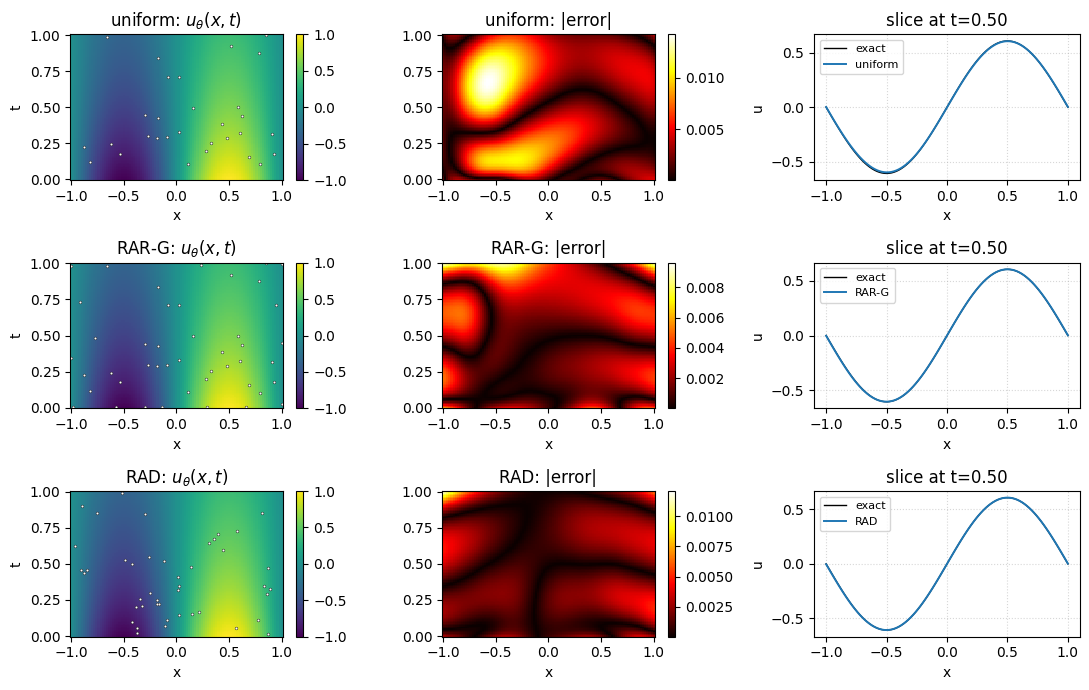

In [24]:
with torch.no_grad():
    u_unif = res_unif['model'](TEST_XT).reshape(nt, nx).numpy()
    u_rar  = res_rar ['model'](TEST_XT).reshape(nt, nx).numpy()
    u_rad  = res_rad ['model'](TEST_XT).reshape(nt, nx).numpy()
u_true = TEST_U.reshape(nt, nx).numpy()
err_unif = np.abs(u_unif - u_true)
err_rar  = np.abs(u_rar  - u_true)
err_rad  = np.abs(u_rad  - u_true)

fig, axes = plt.subplots(3, 3, figsize=(11, 7.0))
for row, (uu, ee, name, pts) in enumerate([
    (u_unif, err_unif, 'uniform', res_unif['final_xt']),
    (u_rar,  err_rar,  'RAR-G',   res_rar ['final_xt']),
    (u_rad,  err_rad,  'RAD',     res_rad ['final_xt']),
]):
    ax = axes[row, 0]
    im = ax.pcolormesh(X_TEST.numpy(), T_TEST.numpy(), uu, shading='auto', cmap='viridis',
                       vmin=u_true.min(), vmax=u_true.max())
    ax.set_title(f'{name}: $u_\\theta(x,t)$'); ax.set_ylabel('t')
    ax.scatter(pts[:, 0], pts[:, 1], s=4, color='white', edgecolors='black', linewidths=0.3)
    fig.colorbar(im, ax=ax)

    ax = axes[row, 1]
    im = ax.pcolormesh(X_TEST.numpy(), T_TEST.numpy(), ee, shading='auto', cmap='hot')
    ax.set_title(f'{name}: |error|'); fig.colorbar(im, ax=ax)

    ax = axes[row, 2]
    ax.plot(xx.numpy(), u_true[nt//2],     color='black', lw=1.0, label='exact')
    ax.plot(xx.numpy(), uu  [nt//2],       color='C0',    lw=1.4, label=f'{name}')
    ax.set_title(f'slice at t={tt[nt//2]:.2f}'); ax.legend(fontsize=8)
    ax.grid(True, ls=':', alpha=0.5)
for ax in axes[:, 0]: ax.set_xlabel('x')
for ax in axes[:, 1]: ax.set_xlabel('x')
for ax in axes[:, 2]: ax.set_xlabel('x'); ax.set_ylabel('u')
plt.tight_layout(); plt.show()


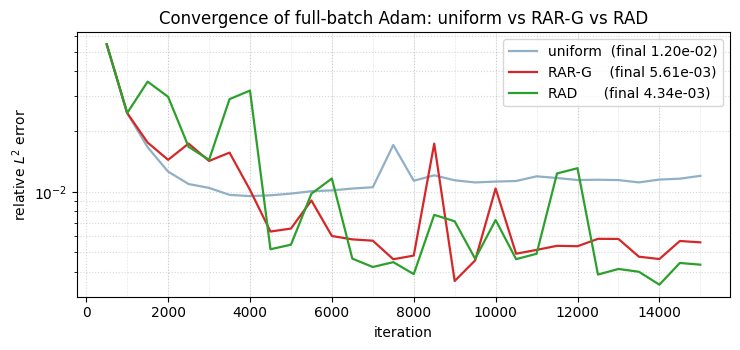

In [25]:
C_UNIF = "#90b0c6"
C_RAR  = '#d62728'
C_RAD  = '#2ca02c'

fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.6))
ax.semilogy(res_unif['history']['iter'], res_unif['history']['l2'],
            color=C_UNIF, lw=1.6, label=f'uniform  (final {res_unif["history"]["l2"][-1]:.2e})')
ax.semilogy(res_rar ['history']['iter'], res_rar ['history']['l2'],
            color=C_RAR,  lw=1.6, label=f'RAR-G    (final {res_rar ["history"]["l2"][-1]:.2e})')
ax.semilogy(res_rad ['history']['iter'], res_rad ['history']['l2'],
            color=C_RAD,  lw=1.6, label=f'RAD      (final {res_rad ["history"]["l2"][-1]:.2e})')
for s in res_rar['snapshots'][1:]:
    ax.axvline(s['iter'], color='gray', ls=':', lw=0.4, alpha=0.4)
ax.set_xlabel('iteration'); ax.set_ylabel(r'relative $L^2$ error')
ax.set_title('Convergence of full-batch Adam: uniform vs RAR-G vs RAD')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


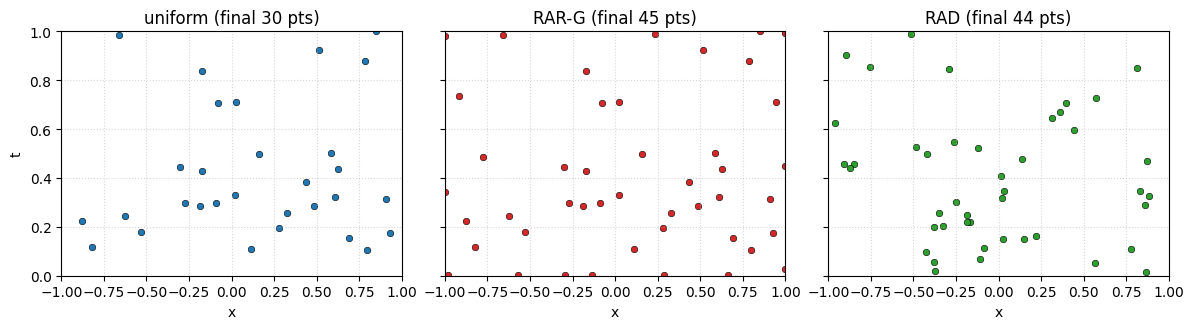

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True, sharey=True)
for ax, (res, name, color) in zip(axes, [
    (res_unif, 'Uniform', '#1f77b4'),
    (res_rar,  'RAR-G',   '#d62728'),
    (res_rad,  'RAD',     '#2ca02c'),
]):
    pts = res['final_xt']
    ax.scatter(pts[:, 0], pts[:, 1], s=22, color=color,
               edgecolors='black', linewidths=0.4)
    ax.set_xlabel('x'); ax.set_xlim(-1, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{name} (final {len(pts)} pts)')
    ax.grid(True, ls=':', alpha=0.5)
axes[0].set_ylabel('t')
plt.tight_layout(); plt.show()


## 7. Discussion

**What you should see.**

1. **Convergence.** The uniform run plateaus once Adam has fitted the residual loss on its fixed $30$ points. RAR-G keeps making progress because each refinement event injects a new Jacobian column at the current worst-residual location. RAD makes progress for a different reason — it does not grow the budget, but at every refresh the $44$ collocation points move toward where the residual is currently large, so the empirical NTK acquires informative directions throughout training rather than only at the start.
2. **Where the points end up.** The RAR-G additions cluster along the boundary regions and near the IC line $t=0$, where the soft IC/BC penalty leaves the residual largest. RAD's points are similarly concentrated in those regions but with a thinner *exploration tail* sustained by the additive constant $c$, which prevents the distribution from collapsing onto a few hot spots.
3. **Importance sampling vs greedy.** RAR-G is a greedy, *deterministic*, monotonically growing strategy; RAD is an unbiased *stochastic* importance sampler with a fixed budget. With the small budgets (tens of points) used here, the two reach similar accuracy because the residual is concentrated enough that even a greedy add is a reasonable approximation of the optimal density. Wu et al. report that RAD becomes preferable as the budget grows, where its variance reduction effect dominates over the greedy bias.

**Numerical reproduction (vs Wu et al. Table 2).** The paper reports the *geometric mean* over 10 runs, while we run a single seed; absolute numbers therefore vary, but the qualitative ordering uniform $\succ$ RAR-G/RAD holds robustly.

**Why the budget matters.** With only $30$ residual points covering a 2D domain, the per-point Jacobian directions matter a lot: each new top-residual point that RAR-G adds, or each RAD draw that lands in a high-residual region, carries information that no uniform point could provide on its own. As the collocation set grows past a few hundred points, the *uniform* baseline becomes harder to beat — uniform tilings have asymptotically optimal coverage in low dimensions. The advantage of RAR-G and RAD in the literature is most pronounced at low budgets and for problems where the residual concentrates locally (sharp fronts, boundary layers, shocks), exactly the §9.2 setting.
